# Merge & Đồng bộ Dữ liệu Thời tiết và Chất lượng Không khí

**Mục tiêu**: Gộp và đồng bộ dữ liệu đã làm sạch từ 2 nguồn thành 1 dataset duy nhất.

**Input**: 
- `processed/weather_cleaned.csv`
- `processed/airquality_cleaned.csv`

**Output**: 
- `processed/final_combined_data.csv` - Dataset cuối cùng
- `reports/merge_summary.csv` - Báo cáo merge

## 1. Import Libraries và Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load dữ liệu đã làm sạch
df_weather = pd.read_csv('../processed/weather_cleaned.csv')
df_aq = pd.read_csv('../processed/airquality_cleaned.csv')

print("="*70)
print("DỮ LIỆU ĐÃ LOAD")
print("="*70)
print(f"\n📊 Weather Data:")
print(f"  - Số dòng: {len(df_weather)}")
print(f"  - Số cột: {len(df_weather.columns)}")
print(f"  - Cột chính: {[col for col in df_weather.columns if not ('missing' in col or 'invalid' in col or 'quality' in col)]}")

print(f"\n🌫️ Air Quality Data:")
print(f"  - Số dòng: {len(df_aq)}")
print(f"  - Số cột: {len(df_aq.columns)}")
print(f"  - Cột chính: {[col for col in df_aq.columns if not ('missing' in col or 'invalid' in col or 'quality' in col)]}")

DỮ LIỆU ĐÃ LOAD

📊 Weather Data:
  - Số dòng: 366
  - Số cột: 14
  - Cột chính: ['time', 'temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 'wind_direction_deg', 'pressure_hPa']

🌫️ Air Quality Data:
  - Số dòng: 366
  - Số cột: 24
  - Cột chính: ['time', 'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']


## 2. Chuyển đổi Thời gian và Kiểm tra Timezone

In [3]:
# Chuyển cột time sang datetime
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_aq['time'] = pd.to_datetime(df_aq['time'])

print("="*70)
print("KIỂM TRA THỜI GIAN & TIMEZONE")
print("="*70)

print(f"\n📅 Weather Data:")
print(f"  - Khoảng thời gian: {df_weather['time'].min()} đến {df_weather['time'].max()}")
print(f"  - Timezone: {df_weather['time'].dt.tz}")
print(f"  - Số ngày: {len(df_weather)}")

print(f"\n📅 Air Quality Data:")
print(f"  - Khoảng thời gian: {df_aq['time'].min()} đến {df_aq['time'].max()}")
print(f"  - Timezone: {df_aq['time'].dt.tz}")
print(f"  - Số ngày: {len(df_aq)}")

# Kiểm tra frequency
print(f"\n🔍 Kiểm tra Frequency:")
df_weather_sorted = df_weather.sort_values('time')
df_aq_sorted = df_aq.sort_values('time')

weather_freq = df_weather_sorted['time'].diff().mode()[0]
aq_freq = df_aq_sorted['time'].diff().mode()[0]

print(f"  - Weather frequency: {weather_freq} (mode)")
print(f"  - Air Quality frequency: {aq_freq} (mode)")

if weather_freq == aq_freq:
    print(f"  ✓ Cả 2 dataset có cùng frequency: Daily")
else:
    print(f"  ⚠️ WARNING: Frequency không khớp!")

KIỂM TRA THỜI GIAN & TIMEZONE

📅 Weather Data:
  - Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00
  - Timezone: None
  - Số ngày: 366

📅 Air Quality Data:
  - Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00
  - Timezone: None
  - Số ngày: 366

🔍 Kiểm tra Frequency:
  - Weather frequency: 1 days 00:00:00 (mode)
  - Air Quality frequency: 1 days 00:00:00 (mode)
  ✓ Cả 2 dataset có cùng frequency: Daily


## 3. Chuẩn bị Dữ liệu cho Merge

In [4]:
print("="*70)
print("CHUẨN BỊ DỮ LIỆU CHO MERGE")
print("="*70)

# Tách cột data và cột flag
weather_data_cols = ['time', 'temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 
                     'wind_direction_deg', 'pressure_hPa']
weather_flag_cols = [col for col in df_weather.columns if col not in weather_data_cols]

aq_data_cols = ['time', 'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']
aq_flag_cols = [col for col in df_aq.columns if col not in aq_data_cols]

print(f"\n📊 Weather Data Columns: {len(weather_data_cols)}")
print(f"   {weather_data_cols}")
print(f"\n🚩 Weather Flag Columns: {len(weather_flag_cols)}")
print(f"   {weather_flag_cols[:5]}... (showing first 5)")

print(f"\n🌫️ Air Quality Data Columns: {len(aq_data_cols)}")
print(f"   {aq_data_cols}")
print(f"\n🚩 Air Quality Flag Columns: {len(aq_flag_cols)}")
print(f"   {aq_flag_cols[:5]}... (showing first 5)")

# Đổi tên cột flag để tránh conflict
weather_flag_rename = {col: f'weather_{col}' for col in weather_flag_cols}
aq_flag_rename = {col: f'aq_{col}' for col in aq_flag_cols}

df_weather_prep = df_weather.rename(columns=weather_flag_rename)
df_aq_prep = df_aq.rename(columns=aq_flag_rename)

print(f"\n✓ Đã đổi tên cột flag để tránh conflict")

CHUẨN BỊ DỮ LIỆU CHO MERGE

📊 Weather Data Columns: 6
   ['time', 'temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 'wind_direction_deg', 'pressure_hPa']

🚩 Weather Flag Columns: 8
   ['temperature_avg_C_missing', 'precipitation_mm_missing', 'wind_speed_kmh_missing', 'wind_direction_deg_missing', 'pressure_hPa_missing']... (showing first 5)

🌫️ Air Quality Data Columns: 7
   ['time', 'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']

🚩 Air Quality Flag Columns: 17
   ['pm10_ugm3_missing', 'pm2_5_ugm3_missing', 'uv_index_missing', 'ozone_ugm3_missing', 'co_ugm3_missing']... (showing first 5)

✓ Đã đổi tên cột flag để tránh conflict


## 4. Kiểm tra Độ Trùng khớp Thời gian

In [5]:
print("="*70)
print("KIỂM TRA ĐỘ TRÙNG KHỚP THỜI GIAN")
print("="*70)

weather_dates = set(df_weather_prep['time'].dt.date)
aq_dates = set(df_aq_prep['time'].dt.date)

# Tìm ngày chung và riêng
common_dates = weather_dates.intersection(aq_dates)
weather_only = weather_dates - aq_dates
aq_only = aq_dates - weather_dates

print(f"\n📊 Thống kê:")
print(f"  - Ngày có trong Weather: {len(weather_dates)}")
print(f"  - Ngày có trong Air Quality: {len(aq_dates)}")
print(f"  - Ngày chung (có cả 2): {len(common_dates)}")
print(f"  - Ngày chỉ có Weather: {len(weather_only)}")
print(f"  - Ngày chỉ có Air Quality: {len(aq_only)}")

# Tính tỷ lệ trùng khớp
total_unique_dates = len(weather_dates.union(aq_dates))
overlap_percentage = (len(common_dates) / total_unique_dates * 100) if total_unique_dates > 0 else 0

print(f"\n📈 Tỷ lệ trùng khớp: {overlap_percentage:.2f}%")

# Hiển thị ngày riêng nếu có
if len(weather_only) > 0:
    print(f"\n⚠️ Ngày chỉ có trong Weather (không có Air Quality):")
    for date in sorted(list(weather_only))[:5]:
        print(f"  - {date}")
    if len(weather_only) > 5:
        print(f"  ... và {len(weather_only) - 5} ngày khác")

if len(aq_only) > 0:
    print(f"\n⚠️ Ngày chỉ có trong Air Quality (không có Weather):")
    for date in sorted(list(aq_only))[:5]:
        print(f"  - {date}")
    if len(aq_only) > 5:
        print(f"  ... và {len(aq_only) - 5} ngày khác")

KIỂM TRA ĐỘ TRÙNG KHỚP THỜI GIAN

📊 Thống kê:
  - Ngày có trong Weather: 366
  - Ngày có trong Air Quality: 366
  - Ngày chung (có cả 2): 366
  - Ngày chỉ có Weather: 0
  - Ngày chỉ có Air Quality: 0

📈 Tỷ lệ trùng khớp: 100.00%


## 5. Merge Dữ liệu

In [6]:
print("="*70)
print("MERGE DỮ LIỆU")
print("="*70)

# Thực hiện INNER JOIN để chỉ giữ ngày có cả 2 nguồn
df_merged = pd.merge(
    df_weather_prep,
    df_aq_prep,
    on='time',
    how='inner',  # Chỉ giữ ngày có cả 2
    suffixes=('_weather', '_aq')
)

print(f"\n✓ Đã merge với INNER JOIN")
print(f"  - Số dòng sau merge: {len(df_merged)}")
print(f"  - Số cột sau merge: {len(df_merged.columns)}")
print(f"  - Mất mát dữ liệu: {len(df_weather_prep) - len(df_merged)} dòng từ Weather, {len(df_aq_prep) - len(df_merged)} dòng từ Air Quality")

# Sắp xếp theo thời gian
df_merged = df_merged.sort_values('time').reset_index(drop=True)

print(f"\n📅 Khoảng thời gian sau merge:")
print(f"  - Từ: {df_merged['time'].min()}")
print(f"  - Đến: {df_merged['time'].max()}")
print(f"  - Tổng số ngày: {len(df_merged)}")

MERGE DỮ LIỆU

✓ Đã merge với INNER JOIN
  - Số dòng sau merge: 366
  - Số cột sau merge: 37
  - Mất mát dữ liệu: 0 dòng từ Weather, 0 dòng từ Air Quality

📅 Khoảng thời gian sau merge:
  - Từ: 2024-01-01 00:00:00
  - Đến: 2024-12-31 00:00:00
  - Tổng số ngày: 366


## 6. Kiểm tra Missing Data sau Merge

In [7]:
print("="*70)
print("KIỂM TRA MISSING DATA SAU MERGE")
print("="*70)

# Chỉ kiểm tra các cột dữ liệu chính (không phải flag)
data_columns = ['temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 
                'wind_direction_deg', 'pressure_hPa',
                'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']

missing_summary = pd.DataFrame({
    'Column': data_columns,
    'Missing_Count': [df_merged[col].isnull().sum() for col in data_columns],
    'Missing_Percentage': [f"{df_merged[col].isnull().sum() / len(df_merged) * 100:.2f}%" for col in data_columns]
})

print("\n📊 Tóm tắt Missing Data:")
print(missing_summary.to_string(index=False))

# Tính tổng missing
total_cells = len(df_merged) * len(data_columns)
total_missing = df_merged[data_columns].isnull().sum().sum()
completeness_rate = ((total_cells - total_missing) / total_cells * 100)

print(f"\n📈 Độ đầy đủ tổng thể: {completeness_rate:.2f}%")
print(f"   - Tổng số ô: {total_cells:,}")
print(f"   - Số ô có dữ liệu: {total_cells - total_missing:,}")
print(f"   - Số ô thiếu: {total_missing:,}")

KIỂM TRA MISSING DATA SAU MERGE

📊 Tóm tắt Missing Data:
            Column  Missing_Count Missing_Percentage
 temperature_avg_C              0              0.00%
  precipitation_mm             12              3.28%
    wind_speed_kmh              0              0.00%
wind_direction_deg            366            100.00%
      pressure_hPa              0              0.00%
         pm10_ugm3              0              0.00%
        pm2_5_ugm3              0              0.00%
          uv_index              0              0.00%
        ozone_ugm3              0              0.00%
           co_ugm3              0              0.00%
           co2_ppm            299             81.69%

📈 Độ đầy đủ tổng thể: 83.18%
   - Tổng số ô: 4,026
   - Số ô có dữ liệu: 3,349
   - Số ô thiếu: 677


## 7. Tạo Cờ Tổng hợp cho Dataset Cuối

In [8]:
print("="*70)
print("TẠO CỜ TỔNG HỢP")
print("="*70)

# Tạo cờ tổng hợp từ cả weather và air quality
all_flag_cols = [col for col in df_merged.columns if 
                 'missing' in col or 'invalid' in col or 'quality_issues' in col]

print(f"\nSố cột cờ: {len(all_flag_cols)}")

# Tạo cờ tổng hợp mới
df_merged['has_any_quality_issues'] = df_merged[all_flag_cols].sum(axis=1) > 0
df_merged['has_any_quality_issues'] = df_merged['has_any_quality_issues'].astype(int)

issues_count = df_merged['has_any_quality_issues'].sum()
issues_percentage = (issues_count / len(df_merged) * 100)

print(f"\n📊 Thống kê chất lượng:")
print(f"  - Số ngày có vấn đề chất lượng: {issues_count}/{len(df_merged)} ({issues_percentage:.2f}%)")
print(f"  - Số ngày không có vấn đề: {len(df_merged) - issues_count}/{len(df_merged)} ({100-issues_percentage:.2f}%)")

# Thống kê chi tiết theo nguồn
weather_issues = df_merged['weather_has_quality_issues'].sum()
aq_issues = df_merged['aq_has_quality_issues'].sum()

print(f"\n📈 Chi tiết theo nguồn:")
print(f"  - Weather có vấn đề: {weather_issues}/{len(df_merged)} ({weather_issues/len(df_merged)*100:.2f}%)")
print(f"  - Air Quality có vấn đề: {aq_issues}/{len(df_merged)} ({aq_issues/len(df_merged)*100:.2f}%)")

TẠO CỜ TỔNG HỢP

Số cột cờ: 25

📊 Thống kê chất lượng:
  - Số ngày có vấn đề chất lượng: 366/366 (100.00%)
  - Số ngày không có vấn đề: 0/366 (0.00%)

📈 Chi tiết theo nguồn:
  - Weather có vấn đề: 366/366 (100.00%)
  - Air Quality có vấn đề: 299/366 (81.69%)


## 8. Sắp xếp Cột theo Logic

In [9]:
print("="*70)
print("SẮP XẾP CỘT THEO LOGIC")
print("="*70)

# Định nghĩa thứ tự cột
column_order = ['time',
                # Weather data
                'temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 
                'wind_direction_deg', 'pressure_hPa',
                # Air quality data
                'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm',
                # Quality flags
                'has_any_quality_issues', 'weather_has_quality_issues', 'aq_has_quality_issues']

# Thêm các cột còn lại (các cột flag chi tiết)
remaining_cols = [col for col in df_merged.columns if col not in column_order]
column_order.extend(sorted(remaining_cols))

# Sắp xếp
df_final = df_merged[column_order].copy()

print(f"\n✓ Đã sắp xếp {len(column_order)} cột")
print(f"\n📋 Cấu trúc cuối cùng:")
print(f"  - Time: 1 cột")
print(f"  - Weather data: 5 cột")
print(f"  - Air quality data: 6 cột")
print(f"  - Quality flags: {len(remaining_cols) + 3} cột")
print(f"  - Tổng: {len(df_final.columns)} cột")

SẮP XẾP CỘT THEO LOGIC

✓ Đã sắp xếp 38 cột

📋 Cấu trúc cuối cùng:
  - Time: 1 cột
  - Weather data: 5 cột
  - Air quality data: 6 cột
  - Quality flags: 26 cột
  - Tổng: 38 cột


## 9. Thống kê Tổng quan Dataset Cuối

In [10]:
print("="*70)
print("THỐNG KÊ TỔNG QUAN DATASET CUỐI")
print("="*70)

print(f"\n📊 Kích thước:")
print(f"  - Số dòng: {len(df_final):,}")
print(f"  - Số cột: {len(df_final.columns):,}")
print(f"  - Khoảng thời gian: {df_final['time'].min()} đến {df_final['time'].max()}")

print(f"\n📈 Thống kê mô tả (các biến chính):")
main_vars = ['temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 'pressure_hPa',
             'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3']
print(df_final[main_vars].describe().round(2))

print(f"\n🔍 5 dòng đầu tiên:")
display_cols = ['time'] + main_vars
print(df_final[display_cols].head())

THỐNG KÊ TỔNG QUAN DATASET CUỐI

📊 Kích thước:
  - Số dòng: 366
  - Số cột: 38
  - Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00

📈 Thống kê mô tả (các biến chính):
       temperature_avg_C  precipitation_mm  wind_speed_kmh  pressure_hPa  \
count             366.00            354.00          366.00        366.00   
mean               29.10              5.10           10.97       1009.23   
std                 1.59              7.24            3.33          2.33   
min                24.30              0.00            4.60       1001.50   
25%                28.00              0.00            8.40       1007.70   
50%                29.00              1.10           10.55       1009.00   
75%                30.10              8.30           13.30       1010.60   
max                33.00             44.30           20.90       1016.20   

       pm10_ugm3  pm2_5_ugm3  uv_index  ozone_ugm3  co_ugm3  
count     366.00      366.00    366.00      366.00   366.00  
mean      

## 10. Tạo Báo cáo Merge

In [11]:
import os

print("="*70)
print("TẠO BÁO CÁO MERGE")
print("="*70)

# Tạo báo cáo
merge_report = {
    'Metric': [
        'Weather records (input)',
        'Air Quality records (input)',
        'Merged records (output)',
        'Records lost in merge',
        'Merge success rate',
        'Time range start',
        'Time range end',
        'Total days',
        'Weather variables',
        'Air Quality variables',
        'Total data variables',
        'Total columns (with flags)',
        'Records with quality issues',
        'Records without issues',
        'Overall data completeness',
        'Merge method'
    ],
    'Value': [
        len(df_weather_prep),
        len(df_aq_prep),
        len(df_final),
        len(df_weather_prep) - len(df_final),
        f"{len(df_final) / len(df_weather_prep) * 100:.2f}%",
        str(df_final['time'].min()),
        str(df_final['time'].max()),
        len(df_final),
        5,
        6,
        11,
        len(df_final.columns),
        issues_count,
        len(df_final) - issues_count,
        f"{completeness_rate:.2f}%",
        'INNER JOIN (only common dates)'
    ]
}

df_merge_report = pd.DataFrame(merge_report)

# Lưu báo cáo
os.makedirs('../reports', exist_ok=True)
report_path = '../reports/merge_summary.csv'
df_merge_report.to_csv(report_path, index=False)

print("\n📄 Báo cáo Merge:")
print(df_merge_report.to_string(index=False))
print(f"\n✓ Đã lưu báo cáo tại: {report_path}")

TẠO BÁO CÁO MERGE

📄 Báo cáo Merge:
                     Metric                          Value
    Weather records (input)                            366
Air Quality records (input)                            366
    Merged records (output)                            366
      Records lost in merge                              0
         Merge success rate                        100.00%
           Time range start            2024-01-01 00:00:00
             Time range end            2024-12-31 00:00:00
                 Total days                            366
          Weather variables                              5
      Air Quality variables                              6
       Total data variables                             11
 Total columns (with flags)                             38
Records with quality issues                            366
     Records without issues                              0
  Overall data completeness                         83.18%
               Merge

## 11. Lưu Dataset Cuối cùng

In [12]:
print("="*70)
print("LƯU DATASET CUỐI CÙNG")
print("="*70)

# Lưu file cuối
output_path = '../processed/final_combined_data.csv'
df_final.to_csv(output_path, index=False)

print(f"\n✓ Đã lưu dataset cuối cùng tại: {output_path}")
print(f"\n📊 Thông tin file:")
print(f"  - Số dòng: {len(df_final):,}")
print(f"  - Số cột: {len(df_final.columns):,}")
print(f"  - Kích thước ước tính: ~{os.path.getsize(output_path) / (1024*1024):.2f} MB")

LƯU DATASET CUỐI CÙNG

✓ Đã lưu dataset cuối cùng tại: ../processed/final_combined_data.csv

📊 Thông tin file:
  - Số dòng: 366
  - Số cột: 38
  - Kích thước ước tính: ~0.04 MB


## 12. Visualizations - Tổng quan Dataset

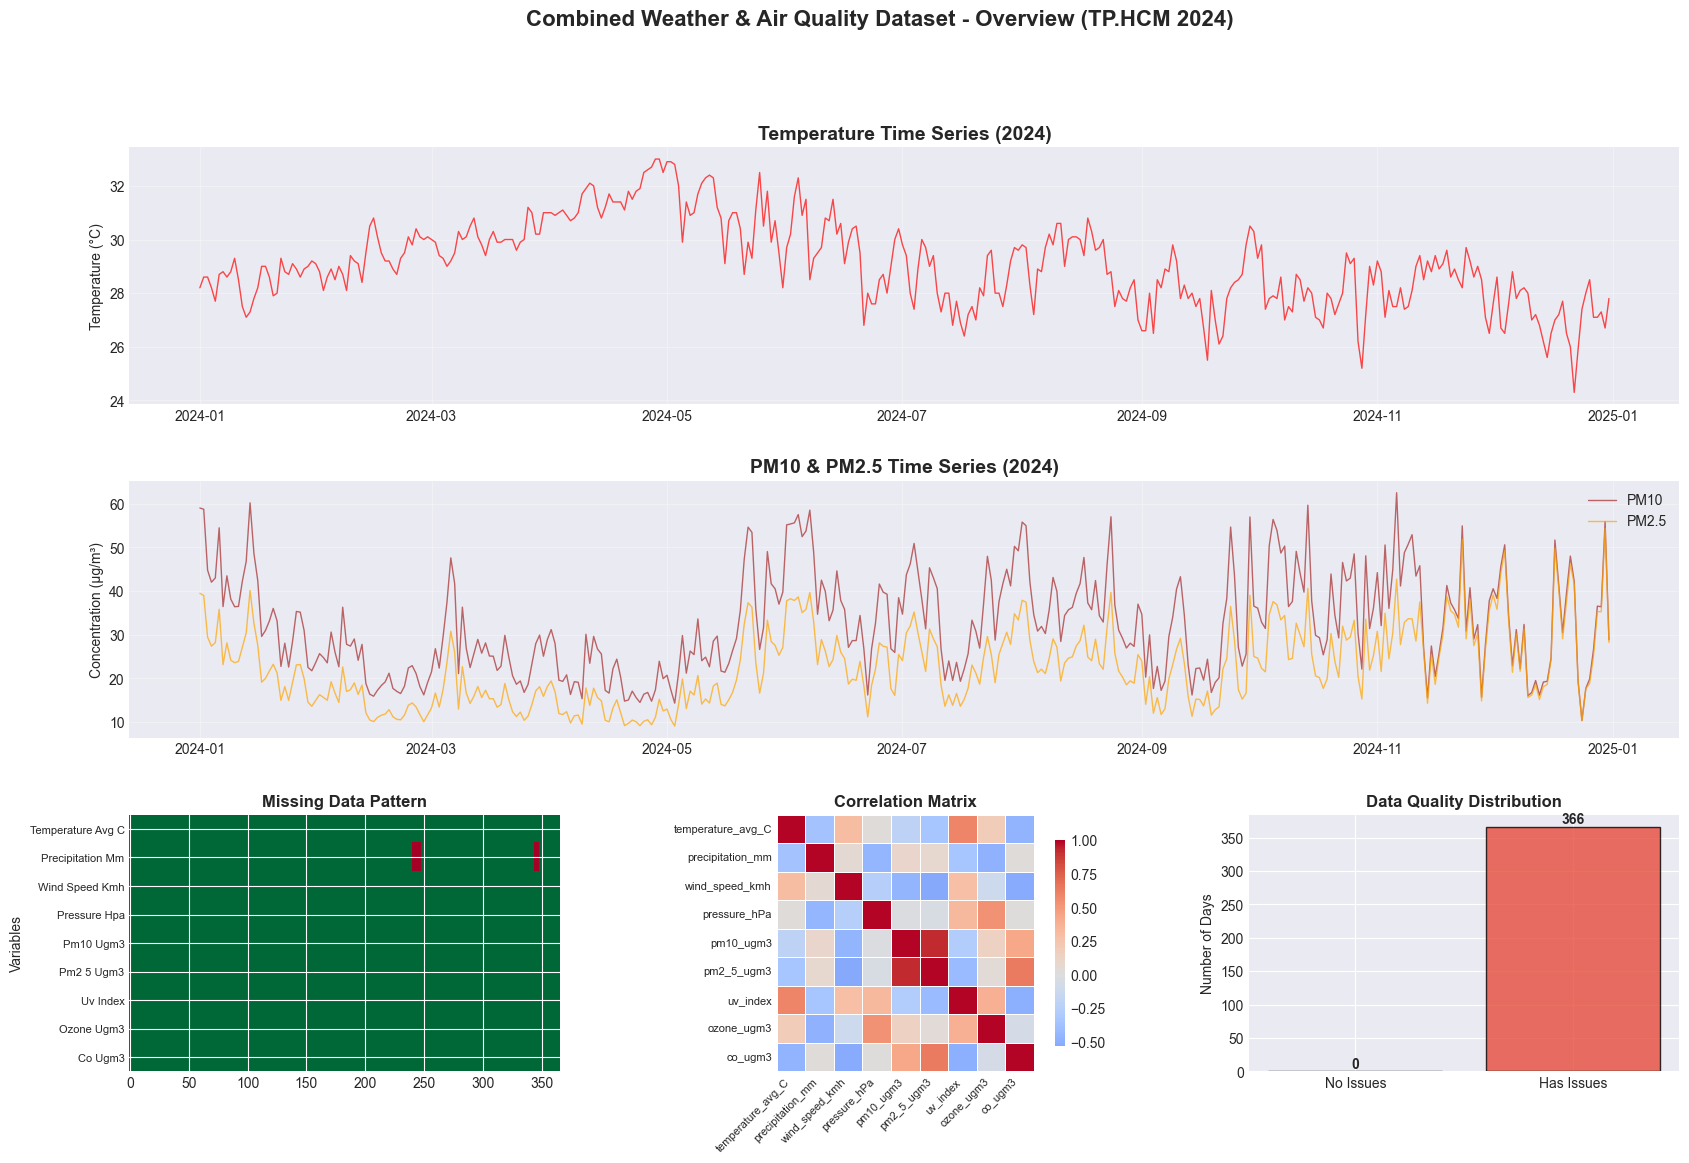


✓ Đã lưu visualization tại: ../reports/merge_visualization.pdf


In [13]:
# Tạo visualizations tổng quan
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Temperature time series
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_final['time'], df_final['temperature_avg_C'], color='red', alpha=0.7, linewidth=1)
ax1.set_title('Temperature Time Series (2024)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, alpha=0.3)

# 2. PM2.5 and PM10 time series
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(df_final['time'], df_final['pm10_ugm3'], label='PM10', color='brown', alpha=0.7, linewidth=1)
ax2.plot(df_final['time'], df_final['pm2_5_ugm3'], label='PM2.5', color='orange', alpha=0.7, linewidth=1)
ax2.set_title('PM10 & PM2.5 Time Series (2024)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Concentration (μg/m³)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. Missing data heatmap
ax3 = fig.add_subplot(gs[2, 0])
missing_viz = df_final[main_vars].isnull().astype(int).T
ax3.imshow(missing_viz, aspect='auto', cmap='RdYlGn_r', interpolation='nearest')
ax3.set_title('Missing Data Pattern', fontsize=12, fontweight='bold')
ax3.set_ylabel('Variables')
ax3.set_yticks(range(len(main_vars)))
ax3.set_yticklabels([v.replace('_', ' ').title() for v in main_vars], fontsize=8)

# 4. Correlation heatmap
ax4 = fig.add_subplot(gs[2, 1])
corr_matrix = df_final[main_vars].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax4)
ax4.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=8)

# 5. Quality issues summary
ax5 = fig.add_subplot(gs[2, 2])
quality_counts = df_final['has_any_quality_issues'].value_counts()
colors_quality = ['#2ecc71', '#e74c3c']
ax5.bar(['No Issues', 'Has Issues'], 
        [quality_counts.get(0, 0), quality_counts.get(1, 0)],
        color=colors_quality, alpha=0.8, edgecolor='black')
ax5.set_title('Data Quality Distribution', fontsize=12, fontweight='bold')
ax5.set_ylabel('Number of Days')
for i, v in enumerate([quality_counts.get(0, 0), quality_counts.get(1, 0)]):
    ax5.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Combined Weather & Air Quality Dataset - Overview (TP.HCM 2024)', 
             fontsize=16, fontweight='bold', y=0.995)

# Lưu visualization
viz_path = '../reports/merge_visualization.pdf'
plt.savefig(viz_path, bbox_inches='tight')
plt.show()

print(f"\n✓ Đã lưu visualization tại: {viz_path}")

## 13. Tóm tắt Cuối cùng

In [14]:
print("="*70)
print("TÓM TẮT QUỴTRÌNH MERGE & ĐỒNG BỘ")
print("="*70)

print(f"\n📁 INPUT FILES:")
print(f"  - processed/weather_cleaned.csv ({len(df_weather_prep)} records)")
print(f"  - processed/airquality_cleaned.csv ({len(df_aq_prep)} records)")

print(f"\n📁 OUTPUT FILES:")
print(f"  - processed/final_combined_data.csv ({len(df_final)} records, {len(df_final.columns)} columns)")
print(f"  - reports/merge_summary.csv")
print(f"  - reports/merge_visualization.pdf")

print(f"\n📊 KEY METRICS:")
print(f"  - Merge success rate: {len(df_final) / len(df_weather_prep) * 100:.2f}%")
print(f"  - Data completeness: {completeness_rate:.2f}%")
print(f"  - Records with quality issues: {issues_count} ({issues_percentage:.2f}%)")
print(f"  - Records without issues: {len(df_final) - issues_count} ({100-issues_percentage:.2f}%)")

print(f"\n📈 DATA VARIABLES:")
print(f"  - Weather: temperature, precipitation, wind_speed, wind_direction, pressure")
print(f"  - Air Quality: PM10, PM2.5, UV_index, ozone, CO, CO2")
print(f"  - Total: {len(main_vars)} measurement variables")

print(f"\n✅ HOÀN TẤT QUÁ TRÌNH MERGE & ĐỒNG BỘ DỮ LIỆU!")
print("="*70)

print(f"\n🎯 NEXT STEPS:")
print(f"  1. Review file: processed/final_combined_data.csv")
print(f"  2. Check quality report: reports/merge_summary.csv")
print(f"  3. Analyze correlations and patterns")
print(f"  4. Generate final PDF report (optional)")
print(f"  5. Ready for analysis/modeling!")

TÓM TẮT QUỴTRÌNH MERGE & ĐỒNG BỘ

📁 INPUT FILES:
  - processed/weather_cleaned.csv (366 records)
  - processed/airquality_cleaned.csv (366 records)

📁 OUTPUT FILES:
  - processed/final_combined_data.csv (366 records, 38 columns)
  - reports/merge_summary.csv
  - reports/merge_visualization.pdf

📊 KEY METRICS:
  - Merge success rate: 100.00%
  - Data completeness: 83.18%
  - Records with quality issues: 366 (100.00%)
  - Records without issues: 0 (0.00%)

📈 DATA VARIABLES:
  - Weather: temperature, precipitation, wind_speed, wind_direction, pressure
  - Air Quality: PM10, PM2.5, UV_index, ozone, CO, CO2
  - Total: 9 measurement variables

✅ HOÀN TẤT QUÁ TRÌNH MERGE & ĐỒNG BỘ DỮ LIỆU!

🎯 NEXT STEPS:
  1. Review file: processed/final_combined_data.csv
  2. Check quality report: reports/merge_summary.csv
  3. Analyze correlations and patterns
  4. Generate final PDF report (optional)
  5. Ready for analysis/modeling!
